# Load libraries

In [14]:
import numpy as np
import itertools, pandas as pd
from models import LinearModel, ChoquetModel
from pymoo_tests import ZDT1, ZDT2, ZDT3, DTLZ1, DTLZ2

import matplotlib.pyplot as plt
from utils import evaluate, visualise_weights

# Modelling

In [15]:
# ZDT calling
linear_model = LinearModel(problem = ZDT1(n_dim = 10), max_iter = 50, random_state = 42)
choquet_model = ChoquetModel(problem = ZDT1(n_dim = 10), max_iter = 50, random_state = 42, method = 2)

# DTLZ calling
# linear_model = LinearModel(problem = DTLZ1(n_dim = 10, n_obj = 3), max_iter = 50, random_state = 42)
# choquet_model = ChoquetModel(problem = DTLZ1(n_dim = 10, n_obj = 3), max_iter = 50, random_state = 42, method = 2)

# Let them solve
linear_model.solve()
choquet_model.solve()

# Summary their performance metrics

print(f"LinearModel :  PF {linear_model.PF.shape}  PS {linear_model.PS.shape}")
print(f"ChoquetModel:  PF {choquet_model.PF.shape} PS {choquet_model.PS.shape}")
evaluate([linear_model, choquet_model])

LinearModel :  PF (730, 2)  PS (730, 10)
ChoquetModel:  PF (586, 2) PS (586, 10)


,hypervolume,n_func_eval,n_non_dominated,n_iter,wallclock_time
LinearModel,5.508809,5456,730,50,0.728995
ChoquetModel,5.505828,5731,586,50,29.239879


# Model visualisation

In [16]:
# for kind in ["symmetric", "absolute", "norm"]:
#     visualise_weights(choquet_model, kind = kind);

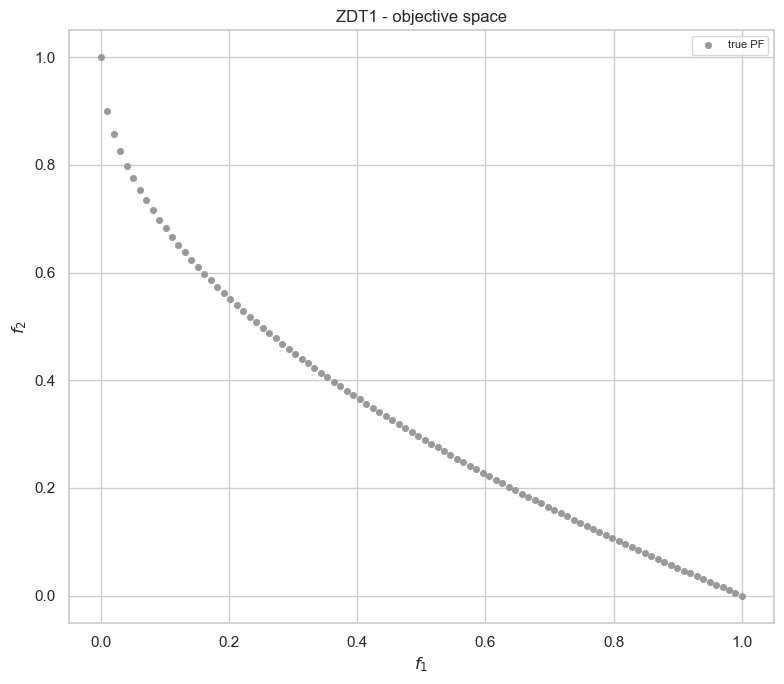

In [17]:
linear_model.visualise("true_pf");

## Linear Model

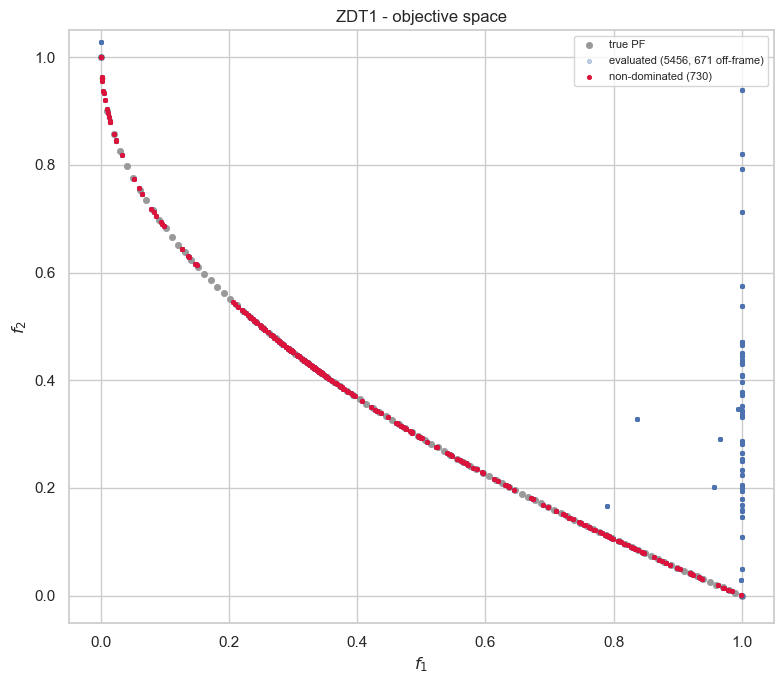

In [18]:
linear_model.visualise("objective");

In [19]:
linear_model.visualise("learning", show = False)

In [20]:
linear_model.visualise("learning", plot_scalarisation = True, show = False)

## Choquet Model

In [21]:
np.all((choquet_model.dec_hist >= 0) & (choquet_model.dec_hist <= 1))

np.True_

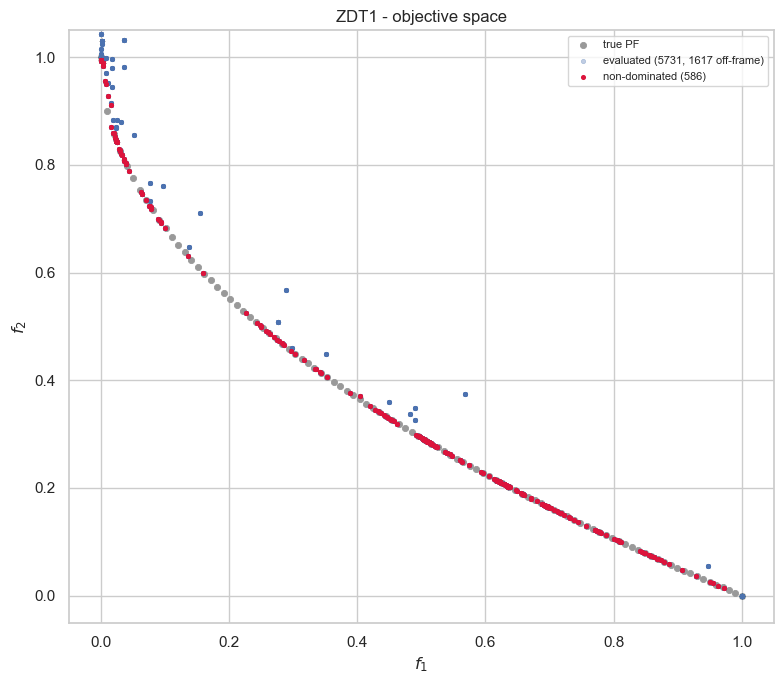

In [22]:
choquet_model.visualise("objective");

In [23]:
choquet_model.visualise("learning", show = False)

In [24]:
choquet_model.visualise("learning", plot_scalarisation = True, show = False)

# Benchmark

Every configuration is solved by both models from the same seed, then scored by `evaluate()` against one shared reference point.

- **ZDT1/2/3** are 2-objective by construction, so they appear once per `n_dim` and ignore `obj_dims`.
- **DTLZ1/2** take `n_obj`, and are skipped when `n_dim <= n_obj` - there would be no tail variables left to carry `g`.
- Hypervolume is comparable **within** a row group only; the reference point differs between configurations, so never compare it across problems or dimensions.

In [25]:
dec_dims   = [10, 20]
obj_dims   = [2, 3, 4, 5]
max_iter   = 50
model_list = [LinearModel, ChoquetModel]
prob_list  = [ZDT1, ZDT2, ZDT3, DTLZ1, DTLZ2]


def build(problem, n_dim, n_obj):
    """This grid cell's problem, or None if the combination does not exist: ZDT is 2-objective by
       construction, and DTLZ needs n_dim > n_obj to leave tail variables to carry g."""
    if problem in (ZDT1, ZDT2, ZDT3):
        return problem(n_dim = n_dim) if n_obj == 2 else None
    return problem(n_dim = n_dim, n_obj = n_obj) if n_dim > n_obj else None


rows = []
for problem, n_dim, n_obj in itertools.product(prob_list, dec_dims, obj_dims):
    prob = build(problem, n_dim, n_obj)
    if prob is None:
        continue

    fitted = [model(problem = prob, max_iter = max_iter, random_state = 42,
                    **(dict(method = 2) if model is ChoquetModel else {}))
              for model in model_list]
    for m in fitted:
        m.solve()

    # evaluate() scores the pair against one shared reference point, and already times each solve
    rows.append(evaluate(fitted).assign(problem = problem.__name__, n_dim = n_dim,
                                        n_obj = prob.n_obj))
    print(problem.__name__, f"n_dim={n_dim}", f"n_obj={prob.n_obj}",
          dict(rows[-1]["wallclock_time"].round(1)))

results = (pd.concat(rows).rename_axis("model").reset_index()
             .set_index(["problem", "n_dim", "n_obj", "model"]).sort_index())
results

ZDT1 n_dim=10 n_obj=2 {'LinearModel': np.float64(0.7), 'ChoquetModel': np.float64(27.6)}
ZDT1 n_dim=20 n_obj=2 {'LinearModel': np.float64(1.4), 'ChoquetModel': np.float64(30.1)}
ZDT2 n_dim=10 n_obj=2 {'LinearModel': np.float64(0.1), 'ChoquetModel': np.float64(14.1)}
ZDT2 n_dim=20 n_obj=2 {'LinearModel': np.float64(0.4), 'ChoquetModel': np.float64(3.2)}
ZDT3 n_dim=10 n_obj=2 {'LinearModel': np.float64(1.0), 'ChoquetModel': np.float64(21.5)}
ZDT3 n_dim=20 n_obj=2 {'LinearModel': np.float64(3.3), 'ChoquetModel': np.float64(43.1)}
DTLZ1 n_dim=10 n_obj=2 {'LinearModel': np.float64(0.4), 'ChoquetModel': np.float64(8.4)}
DTLZ1 n_dim=10 n_obj=3 {'LinearModel': np.float64(0.5), 'ChoquetModel': np.float64(25.7)}
DTLZ1 n_dim=10 n_obj=4 {'LinearModel': np.float64(0.6), 'ChoquetModel': np.float64(314.7)}
DTLZ1 n_dim=10 n_obj=5 {'LinearModel': np.float64(0.8), 'ChoquetModel': np.float64(580.7)}
DTLZ1 n_dim=20 n_obj=2 {'LinearModel': np.float64(1.0), 'ChoquetModel': np.float64(13.9)}
DTLZ1 n_dim=20 n

hypervolume  n_func_eval  n_non_dominated  \
problem n_dim n_obj model                                                      
DTLZ1   10    2     ChoquetModel  3.010581e+05         6281              231   
                    LinearModel   3.001372e+05         4906               56   
              3     ChoquetModel  1.685601e+08         5984              465   
                    LinearModel   1.684158e+08         4763              236   
              4     ChoquetModel  1.548847e+10         9240             1608   
                    LinearModel   1.539411e+10         5258              177   
              5     ChoquetModel  5.474973e+11         9592             1558   
                    LinearModel   5.418052e+11         5137              529   
        20    2     ChoquetModel  2.260562e+06        21756              138   
                    LinearModel   2.251687e+06         9576              144   
              3     ChoquetModel  1.093671e+09        16317              796   
                    LinearModel   1.089375e+09         9366              190   
              4     ChoquetModel  7.249670e+11        35112             2399   
                    LinearModel   7.198671e+11         9891              480   
              5     ChoquetModel  1.078427e+14        22407             1622   
                    LinearModel   1.075161e+14         9135              414   
DTLZ2   10    2     ChoquetModel  3.577621e+00         3047               58   
                    LinearModel   3.550322e+00         2409               10   
              3     ChoquetModel  1.587248e+01         5566              339   
                    LinearModel   1.442246e+01         1947               10   
              4     ChoquetModel  1.607415e+01         3630              176   
                    LinearModel   1.584725e+01         2684               52   
              5     ChoquetModel  4.566114e+01         5412              617   
                    LinearModel   4.551075e+01         2596               74   
        20    2     ChoquetModel  1.331441e+01         6573               91   
                    LinearModel   1.325536e+01         4851               15   
              3     ChoquetModel  9.444014e+01         9072              310   
                    LinearModel   8.168364e+01         4179                4   
              4     ChoquetModel  1.692737e+02         6489               22   
                    LinearModel   1.751898e+02         4767               22   
              5     ChoquetModel  8.660419e+02         8673              319   
                    LinearModel   8.608508e+02         4599               33   
ZDT1    10    2     ChoquetModel  5.505828e+00         5731              586   
                    LinearModel   5.508809e+00         5456              730   
        20    2     ChoquetModel  5.258197e+00        13629              588   
                    LinearModel   5.258446e+00        10878              656   
ZDT2    10    2     ChoquetModel  6.473804e+00         3509              353   
                    LinearModel   6.218821e+00         1749               24   
        20    2     ChoquetModel  5.776991e+00         5124               81   
                    LinearModel   6.521041e-08         4893                2   
ZDT3    10    2     ChoquetModel  7.053477e+00         5940              390   
                    LinearModel   6.191665e+00        10571                2   
        20    2     ChoquetModel  5.492832e+00        19740              515   
                    LinearModel   5.664808e+00        18963              494   

                                  n_iter  wallclock_time  
problem n_dim n_obj model                                 
DTLZ1   10    2     ChoquetModel      50        8.381392  
                    LinearModel       50        0.430146  
              3     ChoquetModel      50       25.669309  
                    LinearModel       50        0.511614  


In [26]:
# hypervolume only compares within a configuration, so pick a winner per row
hv = results["hypervolume"].unstack("model")
hv.assign(winner = hv.idxmax(1), gap_pct = 100 * (hv.max(1) - hv.min(1)) / hv.max(1)).round(4)

model                ChoquetModel   LinearModel        winner   gap_pct
problem n_dim n_obj                                                    
DTLZ1   10    2      3.010581e+05  3.001372e+05  ChoquetModel    0.3059
              3      1.685601e+08  1.684158e+08  ChoquetModel    0.0856
              4      1.548847e+10  1.539411e+10  ChoquetModel    0.6092
              5      5.474973e+11  5.418052e+11  ChoquetModel    1.0397
        20    2      2.260562e+06  2.251687e+06  ChoquetModel    0.3926
              3      1.093671e+09  1.089375e+09  ChoquetModel    0.3928
              4      7.249670e+11  7.198671e+11  ChoquetModel    0.7035
              5      1.078427e+14  1.075161e+14  ChoquetModel    0.3028
DTLZ2   10    2      3.577600e+00  3.550300e+00  ChoquetModel    0.7630
              3      1.587250e+01  1.442250e+01  ChoquetModel    9.1354
              4      1.607420e+01  1.584730e+01  ChoquetModel    1.4116
              5      4.566110e+01  4.551080e+01  ChoquetModel    0.3293
        20    2      1.331440e+01  1.325540e+01  ChoquetModel    0.4435
              3      9.444010e+01  8.168360e+01  ChoquetModel   13.5075
              4      1.692737e+02  1.751898e+02   LinearModel    3.3770
              5      8.660419e+02  8.608508e+02  ChoquetModel    0.5994
ZDT1    10    2      5.505800e+00  5.508800e+00   LinearModel    0.0541
        20    2      5.258200e+00  5.258400e+00   LinearModel    0.0047
ZDT2    10    2      6.473800e+00  6.218800e+00  ChoquetModel    3.9387
        20    2      5.777000e+00  0.000000e+00  ChoquetModel  100.0000
ZDT3    10    2      7.053500e+00  6.191700e+00  ChoquetModel   12.2183
        20    2      5.492800e+00  5.664800e+00   LinearModel    3.0359